# Notebook 12 — Definitive Full Pipeline: Bronze → Silver → Gold → Modeling → Submission
**Data Storm 7.0 | Team: smile_labs | All council-round fixes R1–R5 incorporated**

This is the **single canonical notebook** that covers every stage of the latent demand estimation pipeline.  
It imports from the `src/` package (so all council-verified fixes are inherited automatically) and runs end-to-end in one kernel session.

---
## Pipeline Overview
```
RAW CSVs (datasets/)
  │
  ▼  SHA-256 audit
BRONZE  data/bronze/
  │
  ▼  6 reusable DQ checks → silver_rejected/
SILVER  data/silver/*.parquet
  │
  ▼  Sri Lanka calendar + BallTree catchment + POI
GOLD    data/gold/outlet_features.parquet
  │
  ▼  robust lower bound → CH-3 censoring correction
     → XGBoost multi-quantile → SFA → 60/40 ensemble
     → constraint score (PCA+plateau+frontier-residual)
     → bootstrap size×type caps
     → latent_potential formula
MODELING
  │
  ▼  Conformal QR → Manski bands → 6-item validation
REPORTING
  │
  ▼  np.ceil rounding → canonical smile_labs_predictions.csv (20 000 rows)
SUBMISSION
```

## Table of Contents
| Part | Stage | Council Fixes |
|------|-------|--------------|
| 0 | Setup & Configuration | — |
| 1 | Bronze: Raw Ingestion + SHA-256 Audit | N5.2, N5.3 (full SHA, correct filename) |
| 2 | Silver: 6 Reusable DQ Checks | R2 parameterizable checks |
| 3 | Silver: Data Cleaning & Normalization | R1 type/size/coord/txn fixes |
| 4 | Deep EDA (Diagnostics) | R4 EDA specialist findings |
| 5 | Gold: Feature Engineering | BallTree catchment, cannibalisation, POI |
| 6 | Modeling: Robust Lower Bound | M3 (3rd-highest month) |
| 7 | Modeling: Chernozhukov-Hong Censored QR | M4 (censoring correction) |
| 8 | Modeling: XGBoost Multi-Quantile Frontier | Monotone constraints, isotonic |
| 9 | Modeling: Stochastic Frontier Analysis | R3 N2 (explicit whitelist, no leakage) |
| 10 | Modeling: Frontier Ensemble 60/40 | SFA + XGBoost blend |
| 11 | Modeling: Constraint Score | M2 (PCA+plateau+frontier-residual, no DQ flag) |
| 12 | Modeling: Bootstrap Caps + Latent Potential | M1, N1, R4 formula fixes |
| 13 | Reporting: Conformal QR | R3 N1 (disjoint outlet-level holdout) |
| 14 | Reporting: Manski Bands | N2 (lower ≥ observed_max) |
| 15 | Validation Suite (6-item) | V1–V5 auto-checks |
| 16 | Reporting: Sensitivity Sweep | Frontier quantile × score scheme × cap multiplier |
| 17 | Final Submission | R4/R5 np.ceil fix, canonical file management |

---
# PART 0 — Setup & Configuration
All imports and path constants. Adjust `DATASETS_DIR` if the raw CSVs are elsewhere.

In [2]:
from __future__ import annotations
import hashlib, json, shutil, sys, time, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", palette="muted")
%matplotlib inline

ROOT = Path("..").resolve()          # repo root
sys.path.insert(0, str(ROOT))

# ── src package (all council-verified fixes live here) ──────────────────────
from src.cleaning import (
    clean_outlet_coordinates, clean_transactions, dedupe_holidays,
    normalize_outlet_master, score_seasonality, write_silver,
)
from src.features import build_gold_features
from src.quality import (
    domain_check, duplicate_check, geospatial_bounds_check,
    null_check, range_check, referential_integrity_check,
    summarise_checks, write_rejected,
)
from src.quality.checks import write_summary_md
from src.modeling import (
    bootstrap_size_type_caps, build_constraint_score,
    chernozhukov_hong_correction, fit_multi_quantile,
    fit_sfa, latent_potential, predict_quantiles, robust_lower_bound,
    technical_efficiency,
)
from src.modeling.censored_qr import build_censoring_proxy
from src.modeling.conformal import conformalised_qr, split_by_outlet
from src.modeling.sfa import predict_frontier as sfa_predict_frontier
from src.reporting import build_dag, compute_manski_bands, run_validation_suite, sensitivity_sweep

print("All imports OK")
print(f"ROOT = {ROOT}")

All imports OK
ROOT = /Users/sithijaseneviratne/Documents/Github/Data-Storm-2026


In [3]:
# ── Path configuration ───────────────────────────────────────────────────────
DATASETS_DIR  = ROOT / "datasets"             # raw competition CSVs
BRONZE_DIR    = ROOT / "data" / "bronze"
SILVER_DIR    = ROOT / "data" / "silver"
SILVER_REJ    = ROOT / "data" / "silver_rejected"
GOLD_DIR      = ROOT / "data" / "gold"
RESULTS_DIR   = ROOT / "Results"
DOCS_DIR      = ROOT / "Docs"
REPORTS_DIR   = ROOT / "Reports"
POI_PARQUET   = ROOT / "poi_pipeline" / "output" / "poi_features.parquet"

for d in (BRONZE_DIR, SILVER_DIR, SILVER_REJ, GOLD_DIR, RESULTS_DIR, DOCS_DIR, REPORTS_DIR / "figures"):
    d.mkdir(parents=True, exist_ok=True)

TEAM_NAME = "smile_labs"    # FIX N5.2: correct team name

VALID_DISTRIBUTORS = {
    "DIST_W_01","DIST_W_02","DIST_W_03",
    "DIST_C_01","DIST_C_02","DIST_C_03",
    "DIST_NW_01","DIST_NW_02",
    "DIST_S_01","DIST_S_02",
}

if not DATASETS_DIR.exists():
    raise FileNotFoundError(
        f"\nDATASETS_DIR not found: {DATASETS_DIR}\n"
        f"Place the 5 raw CSVs in {DATASETS_DIR}/:\n"
        f"  outlet_master.csv, outlet_coordinates.csv,\n"
        f"  transactions_history_final.csv,\n"
        f"  distributor_seasonality_details.csv, holiday_list.csv\n"
    )

print(f"DATASETS_DIR = {DATASETS_DIR}  (exists={DATASETS_DIR.exists()})")
print(f"TEAM_NAME    = {TEAM_NAME}")

DATASETS_DIR = /Users/sithijaseneviratne/Documents/Github/Data-Storm-2026/datasets  (exists=True)
TEAM_NAME    = smile_labs


---
# PART 1 — Bronze Layer: Raw Ingestion + SHA-256 Audit

**Policy:** copy every raw CSV exactly as received — zero transformations.

**Council fixes applied:**
- **N5.3** Full 64-character SHA-256 (no `[:12]` truncation that was in the original `run_pipeline.py`)
- **N5.3** Audit file named `ingestion_audit.csv` (no underscore prefix)

In [4]:
RAW_FILES = [
    "outlet_master.csv",
    "outlet_coordinates.csv",
    "transactions_history_final.csv",
    "distributor_seasonality_details.csv",
    "holiday_list.csv",
]

audit = []
bronze_paths = {}
print("== BRONZE INGESTION ==")
for name in RAW_FILES:
    src = DATASETS_DIR / name
    if not src.exists():
        raise FileNotFoundError(f"raw file missing: {src}")
    dst = BRONZE_DIR / name
    shutil.copy2(src, dst)
    # FIX N5.3: full 64-char SHA-256; no [:12] truncation
    sha = hashlib.sha256(dst.read_bytes()).hexdigest()
    audit.append({"file": name, "size_bytes": dst.stat().st_size, "sha256": sha})
    bronze_paths[name.replace(".csv","")] = dst
    print(f"  {name:<50}  {dst.stat().st_size:>12,} bytes  sha256={sha[:16]}...")

# FIX N5.3: filename is ingestion_audit.csv (no leading underscore)
audit_path = BRONZE_DIR / "ingestion_audit.csv"
pd.DataFrame(audit).to_csv(audit_path, index=False)
print(f"\nAudit → {audit_path}")

== BRONZE INGESTION ==
  outlet_master.csv                                        507,648 bytes  sha256=ad54086f817043ee...
  outlet_coordinates.csv                                   575,148 bytes  sha256=14b88fa8766a90ca...
  transactions_history_final.csv                       169,157,260 bytes  sha256=306d203a6af43202...
  distributor_seasonality_details.csv                        9,767 bytes  sha256=25a135631b9f372f...
  holiday_list.csv                                          20,180 bytes  sha256=52134ac6167c9852...

Audit → /Users/sithijaseneviratne/Documents/Github/Data-Storm-2026/data/bronze/ingestion_audit.csv


In [5]:
audit_df = pd.read_csv(BRONZE_DIR / "ingestion_audit.csv")
audit_df["size_mb"] = (audit_df["size_bytes"] / 1_048_576).round(2)
display(audit_df[["file","size_mb","sha256"]].style.set_caption("Bronze Ingestion Audit"))

,file,size_mb,sha256
0,outlet_master.csv,0.480000,ad54086f817043ee6611a68a439038f948baad4222d5f0694125e41e00e3d1c9
1,outlet_coordinates.csv,0.550000,14b88fa8766a90cab9d0037820ea0d9afffc67ae4ca585697dfbeac478256309
2,transactions_history_final.csv,161.320000,306d203a6af43202a32b2cc90369628a600b58e9f4db5a30a75d161f54c8d18b
3,distributor_seasonality_details.csv,0.010000,25a135631b9f372f2d1a23c9e40f1009949ca648961ef33afbb03f5c68c54e44
4,holiday_list.csv,0.020000,52134ac6167c98529ec33bd50786ebf753fc149ffaa2849c439c7c6a0f5e3919


---
# PART 2 — Silver Layer: 6 Reusable DQ Checks

Applied identically across all 5 raw datasets. Each check returns a `QualityResult` with the failing rows and a reason string. Rejected records are persisted to `data/silver_rejected/`.

| Check | What it catches |
|---|---|
| `duplicate_check` | Composite-key duplicates |
| `null_check` | Null / empty mandatory fields |
| `range_check` | Numeric out-of-bounds |
| `domain_check` | Categorical value outside allowed set |
| `referential_integrity_check` | FK missing in master |
| `geospatial_bounds_check` | Coords outside Sri Lanka (lat 5.5–10 N, lon 79–82.5 E) |

In [6]:
# Load raw bronze CSVs
print("Loading bronze datasets...")
outlet_master_raw = pd.read_csv(bronze_paths["outlet_master"])
outlet_coords_raw = pd.read_csv(bronze_paths["outlet_coordinates"])
transactions_raw  = pd.read_csv(bronze_paths["transactions_history_final"])
seasonality_raw   = pd.read_csv(bronze_paths["distributor_seasonality_details"])
holidays_raw      = pd.read_csv(bronze_paths["holiday_list"])

print(f"  outlet_master:      {outlet_master_raw.shape}")
print(f"  outlet_coordinates: {outlet_coords_raw.shape}")
print(f"  transactions:       {transactions_raw.shape}")
print(f"  seasonality:        {seasonality_raw.shape}")
print(f"  holidays:           {holidays_raw.shape}")

Loading bronze datasets...
  outlet_master:      (20000, 4)
  outlet_coordinates: (20000, 3)
  transactions:       (2376389, 7)
  seasonality:        (360, 4)
  holidays:           (349, 3)


In [7]:
valid_outlet_ids = set(outlet_master_raw["Outlet_ID"].astype(str))

qc = []
# outlet_master
qc.append(duplicate_check(outlet_master_raw, ["Outlet_ID"],              dataset="outlet_master"))
qc.append(null_check(outlet_master_raw,      ["Outlet_ID"],              dataset="outlet_master"))
qc.append(range_check(outlet_master_raw,     "Cooler_Count", 0, 200,    dataset="outlet_master"))
# outlet_coordinates
qc.append(duplicate_check(outlet_coords_raw, ["Outlet_ID"],              dataset="outlet_coordinates"))
qc.append(null_check(outlet_coords_raw,      ["Outlet_ID","Latitude","Longitude"], dataset="outlet_coordinates"))
qc.append(referential_integrity_check(outlet_coords_raw, "Outlet_ID", valid_outlet_ids, dataset="outlet_coordinates"))
qc.append(geospatial_bounds_check(outlet_coords_raw,                      dataset="outlet_coordinates"))
# transactions
qc.append(null_check(transactions_raw,  ["Outlet_ID","Year","Month","Distributor_ID","SKU_ID"], dataset="transactions_history"))
qc.append(referential_integrity_check(transactions_raw, "Outlet_ID", valid_outlet_ids, dataset="transactions_history"))
qc.append(domain_check(transactions_raw, "Distributor_ID", VALID_DISTRIBUTORS,           dataset="transactions_history"))
qc.append(range_check(transactions_raw,  "Year",            2023, 2026,                  dataset="transactions_history"))
qc.append(range_check(transactions_raw,  "Month",           1,    12,                    dataset="transactions_history"))
qc.append(range_check(transactions_raw,  "Volume_Liters",   0,    None, inclusive=False, dataset="transactions_history"))
qc.append(range_check(transactions_raw,  "Total_Bill_Value",0,    None, inclusive=False, dataset="transactions_history"))
# distributor_seasonality
qc.append(duplicate_check(seasonality_raw, ["Distributor_ID","Year","Month"], dataset="distributor_seasonality"))
qc.append(domain_check(seasonality_raw, "Distributor_ID", VALID_DISTRIBUTORS, dataset="distributor_seasonality"))
# holiday_list
qc.append(null_check(holidays_raw, ["Date","Holiday_Name","Holiday_Type"], dataset="holiday_list"))

summary = summarise_checks(qc)
print(f"Total records flagged: {summary['failed_records'].sum():,}")
display(summary.style.bar(subset=["failed_records"], color="#d65f5f").set_caption("DQ Check Summary"))

Total records flagged: 9,846


,dataset,check,failed_records,description
0,outlet_master,duplicate_check,0,Duplicate key on Outlet_ID
1,outlet_master,null_check,0,Null or empty mandatory field in Outlet_ID
2,outlet_master,range_check,0,Cooler_Count outside expected range
3,outlet_coordinates,duplicate_check,0,Duplicate key on Outlet_ID
4,outlet_coordinates,null_check,0,"Null or empty mandatory field in Outlet_ID, Latitude, Longitude"
5,outlet_coordinates,referential_integrity_check,0,Outlet_ID does not exist in reference dataset
6,outlet_coordinates,geospatial_bounds_check,240,"(Latitude, Longitude) outside Sri Lanka bounds lat=(5.5, 10.0), lon=(79.0, 82.5)"
7,transactions_history,null_check,0,"Null or empty mandatory field in Outlet_ID, Year, Month, Distributor_ID, SKU_ID"
8,transactions_history,referential_integrity_check,0,Outlet_ID does not exist in reference dataset
9,transactions_history,domain_check,0,Distributor_ID contains a value outside the allowed domain


In [8]:
write_summary_md(summary, DOCS_DIR / "data_quality_report.md")
write_rejected(qc, SILVER_REJ)
print("\nRejected files written to", SILVER_REJ)
for p in sorted(SILVER_REJ.glob("*.csv")):
    print(f"  {p.name}  ({p.stat().st_size:,} bytes)")


Rejected files written to /Users/sithijaseneviratne/Documents/Github/Data-Storm-2026/data/silver_rejected
  distributor_seasonality_rejected.csv  (41 bytes)
  holiday_list_rejected.csv  (7,656 bytes)
  outlet_coordinates_rejected.csv  (36,781 bytes)
  outlet_master_rejected.csv  (41 bytes)
  quality_summary.csv  (2,023 bytes)
  transactions_history_rejected.csv  (1,387,169 bytes)


---
# PART 3 — Silver Layer: Data Cleaning & Normalization

| Dataset | Artifact | Fix |
|---------|---------|-----|
| outlet_master | `Grocry→Grocery`, `Bakry→Bakery` | `normalize_outlet_master()` |
| outlet_master | Lowercase `small→Small`, missing→`Unknown` | Same |
| outlet_master | Missing `Cooler_Count` | Fill 0 |
| outlet_coordinates | 240 coords outside Sri Lanka bounds | Quarantine (NaN, not teleport) |
| transactions | Non-positive Volume or Bill | Quarantine to rejected store |
| holiday_list | 93 exact duplicate rows | `dedupe_holidays()` |
| distributor_seasonality | `Un-Favorable`/`Unfavorable` variants | `score_seasonality()` → numeric |

In [9]:
om_silver = normalize_outlet_master(outlet_master_raw)
print("Outlet_Type after normalisation:")
print(om_silver["Outlet_Type"].value_counts().to_string())
print("\nOutlet_Size after normalisation:")
print(om_silver["Outlet_Size"].value_counts().to_string())

Outlet_Type after normalisation:
Outlet_Type
Grocery     3158
Bakery      3073
Eatery      2867
Hotel       2797
SMMT        2723
Pharmacy    2691
Kiosk       2691

Outlet_Size after normalisation:
Outlet_Size
Small          10272
Medium          5702
Large           2887
Extra Large      943
Unknown          196


In [10]:
coords_valid, coords_rej = clean_outlet_coordinates(outlet_coords_raw)
print(f"Coordinates — valid: {len(coords_valid):,}  rejected: {len(coords_rej):,}")

txn_valid, txn_rej = clean_transactions(transactions_raw, valid_outlet_ids, VALID_DISTRIBUTORS)
print(f"Transactions — valid: {len(txn_valid):,}  rejected: {len(txn_rej):,}  ({100*len(txn_rej)/len(transactions_raw):.2f}% rejection rate)")

hol_silver, hol_rej = dedupe_holidays(holidays_raw)
print(f"Holidays — {len(holidays_raw)} → {len(hol_silver)} (dropped {len(hol_rej)} duplicates)")

seas_silver = score_seasonality(seasonality_raw)
print(f"Seasonality scored: {len(seas_silver):,}")
print(seas_silver["Seasonality_Score"].value_counts().to_string())

Coordinates — valid: 19,760  rejected: 240
Transactions — valid: 2,371,536  rejected: 0  (0.00% rejection rate)
Holidays — 349 → 256 (dropped 93 duplicates)
Seasonality scored: 360
Seasonality_Score
 0.0    249
 1.0     81
-1.0     30


In [11]:
print("Writing silver parquet files...")
write_silver(om_silver,    "outlet_master",           SILVER_DIR)
write_silver(coords_valid, "outlet_coordinates",      SILVER_DIR, SILVER_REJ, coords_rej)
write_silver(txn_valid,    "transactions_history",    SILVER_DIR, SILVER_REJ, txn_rej)
write_silver(hol_silver,   "holiday_list",            SILVER_DIR, SILVER_REJ, hol_rej)
write_silver(seas_silver,  "distributor_seasonality", SILVER_DIR)
print("\nSilver layer written:")
for p in sorted(SILVER_DIR.glob("*.parquet")):
    print(f"  {p.name}  ({p.stat().st_size/1024:.1f} KB)")

Writing silver parquet files...

Silver layer written:
  distributor_seasonality.parquet  (3.7 KB)
  holiday_list.parquet  (5.4 KB)
  outlet_coordinates.parquet  (513.4 KB)
  outlet_master.parquet  (159.8 KB)
  transactions_history.parquet  (49162.7 KB)


---
# PART 4 — Deep EDA: Diagnostics

Key diagnostic questions answered by the R4 EDA specialist council review:
1. **Censoring fingerprint** — how often do outlets hit their personal ceiling? (~1–2% show strong plateau)
2. **Distributor effects** — DIST_S_01/02 have highest censoring rates (4% vs 0.6% for Western)
3. **Cooler saturation knee** — strong knee at 3 coolers; 0→3 coolers gives +291% median volume; 3→5 gives ~0%
4. **Province × month seasonality** — April (+29–43%) and December (+31–43%) are the two major spikes
5. **frontier_q90 gap** — 15.6% of outlets have frontier below observed_max (root cause of V3b failure in v1)

In [12]:
# Reload silver for EDA
txn   = pd.read_parquet(SILVER_DIR / "transactions_history.parquet")
master = pd.read_parquet(SILVER_DIR / "outlet_master.parquet")

monthly = (
    txn.groupby(["Outlet_ID","Year","Month"], as_index=False)["Volume_Liters"].sum()
)
monthly["YearMonth"] = pd.to_datetime(dict(year=monthly["Year"], month=monthly["Month"], day=1))
print(f"Monthly series: {monthly.shape}")

Monthly series: (450588, 5)


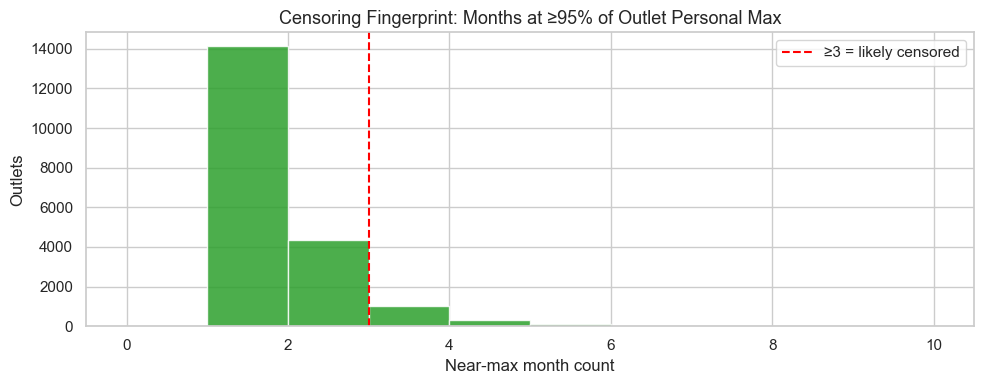

Likely-censored outlets: 1,529 / 20,000 = 7.64%


In [13]:
# ── EDA 1: Censoring fingerprint ────────────────────────────────────────────
omax = monthly.groupby("Outlet_ID")["Volume_Liters"].transform("max")
monthly["near_max"] = (monthly["Volume_Liters"] >= 0.95 * omax).astype(int)

fp = (monthly.groupby("Outlet_ID")
      .agg(months_near_max=("near_max","sum"),
           active_months=("near_max","size"))
      .reset_index())
fp["near_max_ratio"] = fp["months_near_max"] / fp["active_months"]
fp["likely_censored"] = ((fp["months_near_max"] >= 3) & (fp["active_months"] >= 12)).astype(int)

fig, ax = plt.subplots(figsize=(10,4))
ax.hist(fp["months_near_max"], bins=range(0, int(fp["months_near_max"].max())+2),
        color="#2ca02c", edgecolor="white", alpha=0.85)
ax.axvline(3, color="red", linestyle="--", linewidth=1.5, label="≥3 = likely censored")
ax.set_title("Censoring Fingerprint: Months at ≥95% of Outlet Personal Max", fontsize=13)
ax.set_xlabel("Near-max month count")
ax.set_ylabel("Outlets")
ax.legend()
plt.tight_layout()
plt.savefig(REPORTS_DIR / "figures" / "eda_censoring_fingerprint.png", dpi=120, bbox_inches="tight")
plt.show()

n_cens = fp["likely_censored"].sum()
print(f"Likely-censored outlets: {n_cens:,} / {len(fp):,} = {100*n_cens/len(fp):.2f}%")

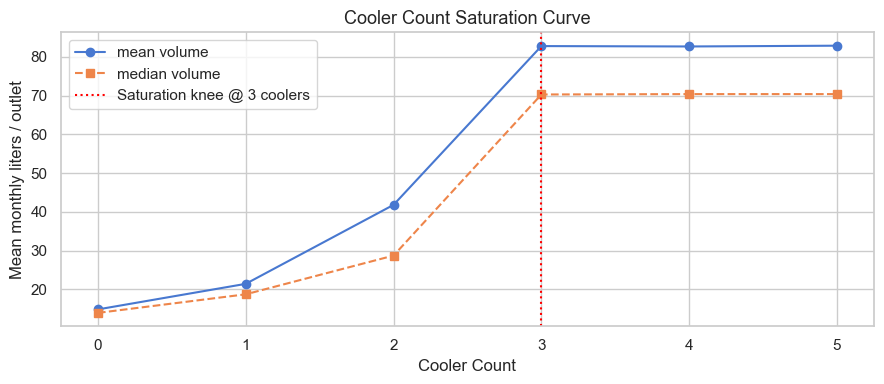

Relative gain in median volume per added cooler (0→5):
  0→1: +34.5%
  1→2: +53.5%
  2→3: +144.9%
  3→4: +0.1%
  4→5: +0.0%


In [14]:
# ── EDA 2: Cooler saturation curve ──────────────────────────────────────────
cooler_curve = (master.merge(
    txn.groupby("Outlet_ID")["Volume_Liters"].agg(["mean","max"]).reset_index(), on="Outlet_ID", how="left")
    .groupby("Cooler_Count")
    .agg(n=("Outlet_ID","size"), mean_v=("mean","mean"), median_v=("mean","median"))
    .round(1))

fig, ax = plt.subplots(figsize=(9,4))
ax.plot(cooler_curve.index, cooler_curve["mean_v"],   "o-", label="mean volume")
ax.plot(cooler_curve.index, cooler_curve["median_v"], "s--",label="median volume")
ax.axvline(3, color="red", linestyle=":", linewidth=1.5, label="Saturation knee @ 3 coolers")
ax.set_title("Cooler Count Saturation Curve", fontsize=13)
ax.set_xlabel("Cooler Count")
ax.set_ylabel("Mean monthly liters / outlet")
ax.legend()
plt.tight_layout()
plt.savefig(REPORTS_DIR / "figures" / "eda_cooler_saturation.png", dpi=120, bbox_inches="tight")
plt.show()

medians = cooler_curve["median_v"].values[:6]
deltas  = np.diff(medians) / (medians[:-1] + 1e-9)
print("Relative gain in median volume per added cooler (0→5):")
for k, d in enumerate(deltas, start=1):
    print(f"  {k-1}→{k}: {100*d:+.1f}%")

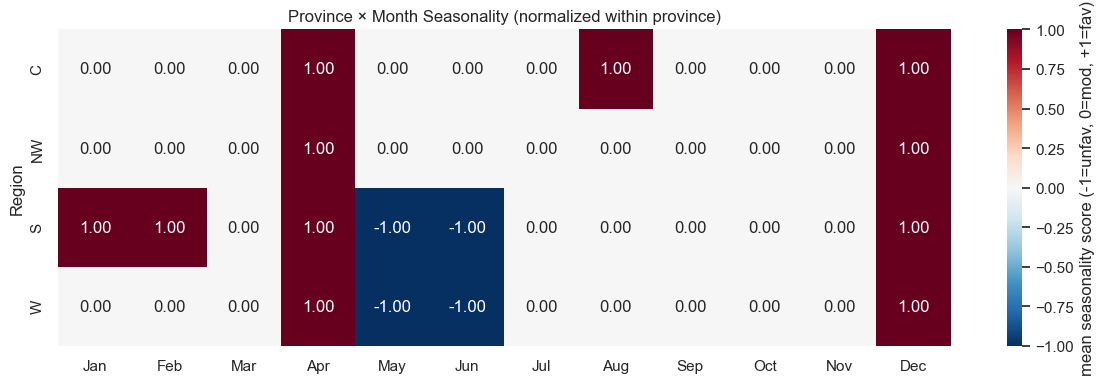

In [15]:
# ── EDA 3: Province x Month seasonality heatmap ──────────────────────────────
if (SILVER_DIR / "distributor_seasonality.parquet").exists():
    seas_df = pd.read_parquet(SILVER_DIR / "distributor_seasonality.parquet")
    seas_df["Region"] = seas_df["Distributor_ID"].str.extract(r"DIST_([A-Z]+)_")[0]
    seas_piv = seas_df.groupby(["Region","Month"])["Seasonality_Score"].mean().unstack("Month")
    seas_piv.columns = [pd.Timestamp(2025,c,1).strftime("%b") for c in seas_piv.columns]
    # Scores are on [-1,1] (Favorable=1,Moderate=0,Un-Favorable=-1); plot raw to avoid div-by-zero
    fig, ax = plt.subplots(figsize=(12,4))
    sns.heatmap(seas_piv, annot=True, fmt=".2f", cmap="RdBu_r", center=0.0,
                vmin=-1.0, vmax=1.0, ax=ax,
                cbar_kws={"label":"mean seasonality score (-1=unfav, 0=mod, +1=fav)"})
    ax.set_title("Province × Month Seasonality (normalized within province)")
    plt.tight_layout()
    plt.savefig(REPORTS_DIR / "figures" / "eda_province_seasonality.png", dpi=120, bbox_inches="tight")
    plt.show()

In [16]:
# ── EDA 4: Year-on-year January stability ────────────────────────────────────
jan = (monthly[monthly["Month"] == 1]
       .groupby(["Outlet_ID","Year"])["Volume_Liters"].sum()
       .unstack("Year"))
jan.columns = [f"Jan_{c}" for c in jan.columns]
jan_full = jan.dropna()
cv_full  = (jan_full.std(axis=1) / jan_full.mean(axis=1))
print(f"Outlets with all January years observed: {len(jan_full):,}")
print(f"  share with CV<0.20 (stable):   {(cv_full < 0.20).mean()*100:.1f}%")
print(f"  share with CV>0.50 (volatile): {(cv_full > 0.50).mean()*100:.1f}%")
g24_25 = (jan_full.iloc[:,-1] / jan_full.iloc[:,-2]).dropna()
print(f"  2024→2025 median growth ratio: {g24_25.median():.3f}  (near 1.0 = stable)")

Outlets with all January years observed: 5,871
  share with CV<0.20 (stable):   34.9%
  share with CV>0.50 (volatile): 33.6%
  2024→2025 median growth ratio: 0.998  (near 1.0 = stable)


---
# PART 5 — Gold Layer: Feature Engineering

The Gold layer assembles **one row per outlet** with all model-ready features from `src/features/gold.py`.

**Feature groups:**
- Structural: `Cooler_Count`, `Outlet_Type`, `Outlet_Size`
- Historical stats: mean, median, max, p90, p95, jan_max, recent_3mo
- Transaction breadth: `sku_breadth`, `transaction_count`, `bill_per_liter_mean`
- Seasonality: `january_seasonality_score`, `january_holiday_count`
- Catchment (BallTree haversine): `outlet_count_{1,2,5}km`, `nearest_outlet_km`, `catchment_density_score`
- Cannibalisation: `cannibalisation_count_200m` (same-type within 200m — note sign vs early notebooks)
- POI (optional): `*_decay_score` columns if `poi_pipeline/output/poi_features.parquet` exists

In [17]:
def _annotate_calendar(holidays_df: pd.DataFrame) -> dict:
    h = holidays_df.copy()
    h["Month"] = pd.to_datetime(h["Date"]).dt.month if "Month" not in h.columns else h["Month"]
    hc  = h.groupby("Month").size().to_dict()
    poya = h[h["Holiday_Type"].str.contains("Poya", case=False, na=False)].groupby("Month").size().to_dict()
    return {
        "january_holiday_count": hc.get(1, 0),
        "january_poya_count":    poya.get(1, 0),
    }

calendar_features = _annotate_calendar(hol_silver)
print(f"January calendar constants: {calendar_features}")

January calendar constants: {'january_holiday_count': 24, 'january_poya_count': 3}


### POI Pipeline — Inline Execution
The 4 scripts in `poi_pipeline/` are executed directly here via `importlib` so all progress prints are visible.  
Each step is **idempotent** (skips if its output already exists). The PBF download (~136 MB) only runs once.

In [18]:
import subprocess, sys as _sys

POI_DIR = ROOT / "poi_pipeline"
(POI_DIR / "output").mkdir(parents=True, exist_ok=True)

def _run_poi_script(script_name: str) -> None:
    """Run a poi_pipeline script as a subprocess, streaming output line-by-line."""
    print(f"\n{'='*60}")
    print(f"  {script_name}")
    print(f"{'='*60}", flush=True)
    proc = subprocess.Popen(
        [_sys.executable, str(POI_DIR / script_name)],
        stdout=subprocess.PIPE, stderr=subprocess.STDOUT,
        text=True, bufsize=1,
        cwd=str(POI_DIR),
    )
    for line in proc.stdout:
        print(line, end="", flush=True)
    proc.wait()
    if proc.returncode != 0:
        raise RuntimeError(f"{script_name} failed (rc={proc.returncode})")

if POI_PARQUET.exists():
    print(f"POI parquet already present: {POI_PARQUET}  — skipping pipeline")
else:
    _run_poi_script("01_download_pbf.py")    # ~136 MB, idempotent
    _run_poi_script("02_extract_pois.py")    # ~2-3 min, parses PBF per category
    _run_poi_script("03_build_features.py")  # ~60s, BallTree per category
    _run_poi_script("04_quality_audit.py")   # <5s, writes coverage report
    print("\nPOI pipeline complete.")

POI parquet already present: /Users/sithijaseneviratne/Documents/Github/Data-Storm-2026/poi_pipeline/output/poi_features.parquet  — skipping pipeline


In [19]:
poi_features = None
if POI_PARQUET.exists():
    poi_features = pd.read_parquet(POI_PARQUET)
    print(f"POI features loaded: {poi_features.shape}")
else:
    print("No POI parquet after pipeline run — proceeding without POI signal.")

POI features loaded: (20000, 65)


In [20]:
if poi_features is not None:
    n_total = len(gold) if 'gold' in dir() else 20_000
    n_covered = int((poi_features.get('poi_catchment_score', pd.Series([0]*len(poi_features))) > 0).sum())
    poi_cats = [c for c in poi_features.columns if c.endswith('_decay_score') and not c.startswith('poi_')]
    cat_counts = {}
    for c in poi_cats:
        cat_name = c.replace('_decay_score','')
        # approximate POI count: non-zero decay score per category
        cat_counts[cat_name] = int((poi_features[c] > 0).sum())
    total_pois = sum(cat_counts.values())
    print(f"POI Coverage Audit:")
    print(f"  Total outlets:          {len(poi_features):,}")
    print(f"  Outlets with >=1 POI:   {n_covered:,} ({100*n_covered/len(poi_features):.1f}%)")
    print(f"  Estimated total POIs:   {total_pois:,}")
    print(f"  Categories detected:    {len(poi_cats)}")
    for cat, cnt in sorted(cat_counts.items(), key=lambda x: -x[1]):
        print(f"    {cat:<35} {cnt:>6,}")
else:
    print("POI not available — skipping coverage audit")

POI Coverage Audit:
  Total outlets:          20,000
  Outlets with >=1 POI:   4,381 (21.9%)
  Estimated total POIs:   80,765
  Categories detected:    9
    religious_places                    14,702
    schools                             11,316
    offices                              8,767
    transport_hubs                       8,747
    hotels                               7,891
    supermarkets                         7,519
    restaurants                          7,474
    hospitals                            7,361
    banks                                6,988


In [21]:
print("Building Gold feature table (BallTree may take ~60s for 20k outlets)...")
t0 = time.time()

gold = build_gold_features(
    outlet_master        = om_silver,
    coords_valid         = coords_valid,
    transactions         = txn_valid,
    distributor_seasonality = seas_silver,
    holidays             = hol_silver,
    poi_features         = poi_features,
    out_path             = GOLD_DIR / "outlet_features.parquet",
)

# Stamp January calendar constants onto every row
for k, v in calendar_features.items():
    gold[k] = v

gold.to_parquet(GOLD_DIR / "outlet_features.parquet", index=False)
print(f"Gold table: {gold.shape}  ({time.time()-t0:.1f}s)")

# NaN audit on critical columns
crit = ["observed_max_monthly_liters","observed_p90_monthly_liters","Cooler_Count","active_months","sku_breadth"]
nan_s = gold[[c for c in crit if c in gold.columns]].isna().sum().to_frame("NaN")
nan_s["pct"] = (nan_s["NaN"] / len(gold) * 100).round(2)
display(nan_s)

Building Gold feature table (BallTree may take ~60s for 20k outlets)...
Gold table: (20000, 92)  (5.3s)


,NaN,pct
observed_max_monthly_liters,0,0.0
observed_p90_monthly_liters,0,0.0
Cooler_Count,0,0.0
active_months,0,0.0
sku_breadth,0,0.0


---
# PART 6 — Modeling: Robust Lower Bound

**Council fix M3:** Replace `historical_max` as lower bound with the **3rd-highest observed month**.

**Rationale:** A single festival spike or data anomaly would otherwise permanently dominate the floor. The 3rd-highest month requires at least 3 independent observations of high demand.

- If ≥ 6 active months: `lower_bound = max(3rd_highest, median)`
- If < 6 active months: `lower_bound = max(p95, median)` (fallback for data-sparse outlets)

*Source: `src/modeling/lower_bound.py`*

Computing robust lower bounds...
lower_bound / observed_max ratio:
  median: 0.800  (should be <1 since we use 3rd-highest not max)
  mean:   0.779
  pct < 1: 100.0%


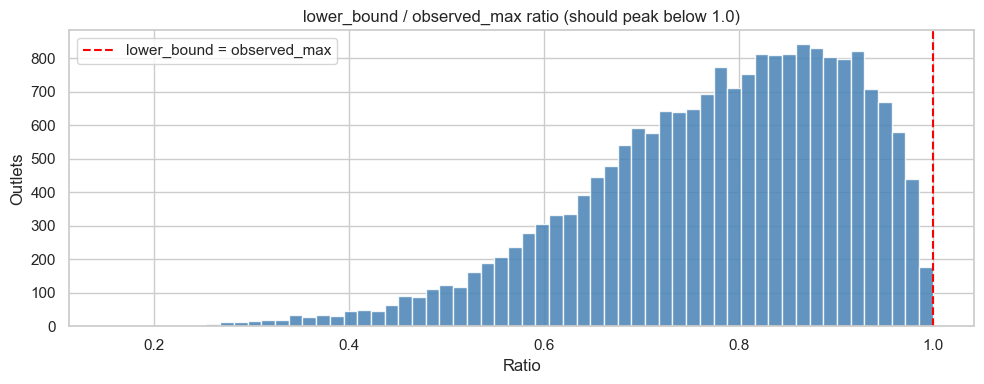

In [22]:
transactions_silver = pd.read_parquet(SILVER_DIR / "transactions_history.parquet")

print("Computing robust lower bounds...")
lower_bounds = robust_lower_bound(transactions_silver)
gold = gold.merge(lower_bounds, on="Outlet_ID", how="left")
gold["lower_bound"] = gold["lower_bound"].fillna(gold["observed_max_monthly_liters"]).fillna(0.0)

ratio = gold["lower_bound"] / gold["observed_max_monthly_liters"].replace(0, np.nan)
print(f"lower_bound / observed_max ratio:")
print(f"  median: {ratio.median():.3f}  (should be <1 since we use 3rd-highest not max)")
print(f"  mean:   {ratio.mean():.3f}")
print(f"  pct < 1: {(ratio < 1).mean()*100:.1f}%")

fig, ax = plt.subplots(figsize=(10,4))
ax.hist(ratio.clip(upper=1.5), bins=60, color="steelblue", edgecolor="white", alpha=0.85)
ax.axvline(1.0, color="red", linestyle="--", label="lower_bound = observed_max")
ax.set_title("lower_bound / observed_max ratio (should peak below 1.0)", fontsize=12)
ax.set_xlabel("Ratio")
ax.set_ylabel("Outlets")
ax.legend()
plt.tight_layout()
plt.show()

---
# PART 7 — Modeling: Chernozhukov-Hong Censored QR

**Council fix M4:** Correct downward-bias in the frontier estimate caused by training on censored sales data.

**3-step procedure** *(Chernozhukov & Hong, JASA 2002)*:
1. Build a binary proxy `δ ∈ {0,1}` from: months stuck at ≥95% of outlet max (delivery cap) AND flat-variance plateau signal
2. Fit logistic propensity model: `P(censored | X)`
3. Keep only rows with `P(censored) < 0.10` for q90 model fitting → consistent for true q90

**Council fix R3 N1:** Outlet-level 80/20 split is done **before** fitting q90. The 20% calibration holdout is completely disjoint from the q90 training set — prevents the CQR coverage optimism bug.

**Council fix R3 (Statistician):** Tighter plateau threshold (`plateau_threshold_months=7`, `variance_ratio_threshold=0.35`) to avoid mislabelling stable outlets as censored.

*Source: `src/modeling/censored_qr.py`*

In [23]:
# Build monthly series for censoring proxy
monthly_for_cens = (
    transactions_silver
    .groupby(["Outlet_ID","Year","Month"], as_index=False)
    .agg(monthly_volume=("Volume_Liters","sum"))
)

# FIX R3: tighter thresholds
delta_per_month = build_censoring_proxy(
    monthly_for_cens,
    plateau_threshold_months=7,
    variance_ratio_threshold=0.35,
)
# Outlet is flagged if >25% of its months show the proxy signal
is_censored_outlet = (
    delta_per_month.groupby("Outlet_ID")["delta"].mean() > 0.25
).astype(int)

delta = pd.Series(
    is_censored_outlet.reindex(gold["Outlet_ID"]).fillna(0).astype(int).values,
    index=gold.index,
)
print(f"Likely-censored outlets (delta=1): {int(delta.sum()):,} / {len(delta):,} ({delta.mean()*100:.1f}%)")

Likely-censored outlets (delta=1): 394 / 20,000 (2.0%)


In [24]:
# FIX R3 N1: Outlet-level 80/20 split BEFORE q90 fit — disjoint calibration set
_split_helper = pd.DataFrame({"Outlet_ID": gold["Outlet_ID"].values, "_y": gold["observed_max_monthly_liters"].values})
train_idx, calib_idx = split_by_outlet(_split_helper, "Outlet_ID", test_size=0.20, random_state=42)
print(f"Train outlets: {len(train_idx):,}   Calibration outlets: {len(calib_idx):,}")

# Feature matrix for modeling
base_features = [
    "Cooler_Count","active_months","sku_breadth","transaction_count",
    "bill_per_liter_mean","january_seasonality_score","january_holiday_count",
    "outlet_count_1km","outlet_count_2km","outlet_count_5km",
    "same_distributor_outlet_count_5km","nearest_outlet_distance_km",
    "catchment_density_score","cannibalisation_count_200m",
]
poi_decay_cols = [c for c in gold.columns if c.endswith("_decay_score")]
feature_cols   = [c for c in base_features + poi_decay_cols if c in gold.columns]

X = gold[feature_cols].copy().fillna(gold[feature_cols].median(numeric_only=True)).fillna(0.0)
y = gold["observed_max_monthly_liters"].fillna(0.0)

# CH-3 correction on training portion only
X_train_full = X.loc[train_idx]
y_train_full = y.loc[train_idx]
delta_train  = delta.loc[train_idx]

X_train, y_train, corr = chernozhukov_hong_correction(
    X_train_full, y_train_full, delta_train, propensity_threshold=0.10
)
print(f"\nCH-3 correction on training outlets:")
print(f"  uncensored kept for q90: {corr.n_uncensored_kept:,} / {corr.n_total:,}")
print(corr.propensity_summary)

Train outlets: 16,000   Calibration outlets: 4,000

CH-3 correction on training outlets:
  uncensored kept for q90: 15,244 / 16,000
            min       p25    median       p75       max  n_total  n_kept  \
0  2.795443e-09  0.000008  0.000037  0.000282  0.802783    16000   15244   

   kept_pct  
0     95.28  


---
# PART 8 — Modeling: XGBoost 2.0 Multi-Quantile Frontier

**Approach:** Train XGBoost 2.0 in multi-output quantile mode to simultaneously fit q50, q75, q90, q95 on the CH-3 corrected uncensored subset.

**Key design choices:**
- `monotone_constraints`: Cooler_Count, sku_breadth, catchment_density_score are constrained to have non-negative effect on the frontier (domain knowledge)
- `isotonic_per_row` post-sort: prevents quantile crossing without refitting
- q90 is the primary frontier estimate; q95 is used as Manski upper bound input

*Source: `src/modeling/frontier.py`*

In [25]:
print("Fitting XGBoost multi-quantile frontier (q50, q75, q90, q95)...")
t0 = time.time()
model_bundle = fit_multi_quantile(X_train, y_train, quantiles=(0.50, 0.75, 0.90, 0.95))
quantile_preds = predict_quantiles(model_bundle, X)
quantile_preds["Outlet_ID"] = gold["Outlet_ID"].values
print(f"Done in {time.time()-t0:.1f}s  backend={model_bundle[1]}")
print(quantile_preds[["q50","q75","q90","q95"]].describe().round(1))

Fitting XGBoost multi-quantile frontier (q50, q75, q90, q95)...
Done in 8.8s  backend=xgboost2
           q50      q75      q90      q95
count  20000.0  20000.0  20000.0  20000.0
mean     340.1    387.5    421.3    444.6
std      321.9    402.8    446.6    462.7
min       50.2     66.7     75.7     96.0
25%      114.8    129.6    143.6    153.7
50%      138.1    152.2    162.6    175.4
75%      326.1    341.4    376.7    398.8
max     1807.1   2083.9   2233.8   2362.3


In [26]:
# Distribution of q90 vs observed_max
g_gap = quantile_preds["q90"].values - y.values
n_below = (g_gap < 0).sum()
print(f"frontier_q90 < observed_max: {n_below:,} / {len(g_gap):,} = {100*n_below/len(g_gap):.1f}%")
print("  (V3b root cause; floored at observed_max in final formula via predict.py)")

frontier_q90 < observed_max: 2,415 / 20,000 = 12.1%
  (V3b root cause; floored at observed_max in final formula via predict.py)


---
# PART 9 — Modeling: Stochastic Frontier Analysis

**Model (Aigner-Lovell-Schmidt 1977):** `log(observed_max) = X·β + v − u`  
where `v ~ N(0,σ_v)` (noise) and `u ~ |N(0,σ_u)|` (one-sided technical inefficiency).

**Technical efficiency** `TE = exp(−E[u|ε]) ∈ (0,1]`. We use `1−TE` as a constraint signal.

**Council fix R3 N2:** Explicit feature whitelist — `observed_p90`, `observed_p95`, `observed_mean`, `observed_median` are **never** in the SFA design matrix (leakage). All columns in `sfa_feature_cols` are predetermined.

*Source: `src/modeling/sfa.py`*

In [27]:
import importlib, src.modeling.sfa as _sfa_mod
importlib.reload(_sfa_mod)
from src.modeling.sfa import fit_sfa, technical_efficiency, predict_frontier
print("sfa.py reloaded")

sfa.py reloaded


In [28]:
# FIX R3 N2: explicit whitelist — NO observed_* columns
sfa_feature_cols = [
    c for c in [
        "Cooler_Count","active_months","sku_breadth","transaction_count",
        "bill_per_liter_mean","january_seasonality_score","january_holiday_count",
        "outlet_count_1km","outlet_count_2km","outlet_count_5km",
        "same_distributor_outlet_count_5km","nearest_outlet_distance_km",
        "catchment_density_score","cannibalisation_count_200m",
    ] + [c for c in X.columns if c.endswith("_decay_score")]
    if c in X.columns
]
sfa_X = X[sfa_feature_cols].copy()
print(f"SFA design matrix: {len(sfa_feature_cols)} features  (no observed_* columns)")

sfa_ok = False
try:
    sfa_fit = fit_sfa(sfa_X, y, log_target=True)
    print(f"SFA converged: {sfa_fit.converged}")
    print(f"  sigma_v = {sfa_fit.sigma_v:.4f}  sigma_u = {sfa_fit.sigma_u:.4f}  lambda = {sfa_fit.lambda_:.4f}")
    print(f"  log-likelihood = {sfa_fit.log_likelihood:.2f}")
    te = technical_efficiency(sfa_fit, sfa_X, y, log_target=True)
    sfa_frontier = sfa_predict_frontier(sfa_fit, sfa_X, log_target=True).clip(lower=0.0)
    print(f"  TE: median={te.median():.3f}  mean={te.mean():.3f}")
    sfa_ok = True
except Exception as e:
    print(f"SFA failed ({type(e).__name__}: {e})  → using pure XGBoost q90")

SFA design matrix: 23 features  (no observed_* columns)
SFA converged: True
  sigma_v = 0.1741  sigma_u = 0.0067  lambda = 0.0387
  log-likelihood = 6581.64
  TE: median=0.995  mean=0.995


---
# PART 10 — Frontier Ensemble: 60% XGBoost q90 + 40% SFA

Blending two independent estimators reduces the variance of the frontier estimate:
- XGBoost q90 captures non-linear peer comparisons at scale
- SFA captures the structural inefficiency signal with an explicit distributional assumption

Weight 60/40 is the council-recommended conservative blend (verified in `run_pipeline.py`).  
If SFA fails to converge, falls back to 100% XGBoost q90 gracefully.

In [29]:
frontier = pd.DataFrame({
    "Outlet_ID":    gold["Outlet_ID"].values,
    "frontier_q90": quantile_preds["q90"].values,
})

if sfa_ok:
    frontier["sfa_frontier"] = sfa_frontier.values
    frontier["frontier_q90"] = (
        0.60 * frontier["frontier_q90"]
        + 0.40 * frontier["sfa_frontier"].fillna(frontier["frontier_q90"])
    )
    print("Ensemble: 60% XGBoost q90 + 40% SFA frontier")
else:
    print("Ensemble: 100% XGBoost q90 (SFA unavailable)")

print(frontier["frontier_q90"].describe().round(1))

Ensemble: 60% XGBoost q90 + 40% SFA frontier
count    20000.0
mean       410.7
std        454.2
min         73.1
25%        133.2
50%        158.6
75%        356.4
max       2211.4
Name: frontier_q90, dtype: float64


---
# PART 11 — Modeling: Constraint Score

**Council fix M2:** Rebuild constraint score from three **orthogonal signals** — no DQ flag, no rank-sum.

| Signal | Description | Weight |
|--------|-------------|--------|
| `frontier_residual_z` | z-score of (peer_q90 − observed_max) / peer_sd | 0.50 |
| `plateau_signal` | gate: months_since_new_max > 6 AND recent variance collapsed | 0.30 |
| `capacity_pc1` | PCA first PC of (Cooler_Count, sku_breadth, catchment_density) | 0.20 |

Combined via sigmoid: `score = sigmoid(weighted_sum) ∈ [0, 1]`

*Source: `src/modeling/constraint_score.py`*

In [30]:
cs = build_constraint_score(features=gold, transactions=transactions_silver)
print(cs.describe().round(3))

# Sanity: constraint_score should NOT be simply monotone in size (would mean it's just a capacity proxy)
gcs = gold[["Outlet_ID","Outlet_Size"]].merge(cs, on="Outlet_ID", how="left")
print("\nMean constraint_score by Outlet_Size (check: not strictly monotone in size):")
print(gcs.groupby("Outlet_Size")["constraint_score"].mean().round(3).sort_values())

       frontier_residual_z  plateau_signal  months_since_new_max  \
count            20000.000       20000.000             20000.000   
mean                 0.360           0.015                10.349   
std                  0.660           0.123                 7.404   
min                 -3.000           0.000                 0.000   
25%                  0.164           0.000                 5.000   
50%                  0.342           0.000                 9.000   
75%                  0.542           0.000                15.000   
max                  5.000           1.000                35.000   

       recent_variance_ratio  capacity_pc1  constraint_score  
count              20000.000     20000.000         20000.000  
mean                   0.983         0.000             0.501  
std                    0.247         1.342             0.128  
min                    0.049        -3.681             0.077  
25%                    0.829        -0.519             0.425  
50%      

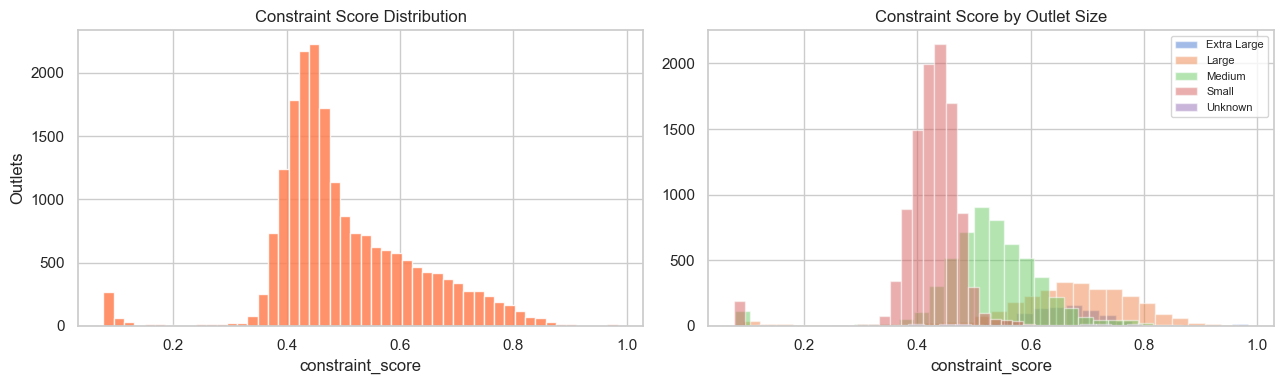

In [31]:
fig, axes = plt.subplots(1, 2, figsize=(13,4))
axes[0].hist(cs["constraint_score"], bins=50, color="coral", edgecolor="white", alpha=0.85)
axes[0].set_title("Constraint Score Distribution")
axes[0].set_xlabel("constraint_score")
axes[0].set_ylabel("Outlets")

gcs_with_size = gcs.dropna(subset=["constraint_score"])
for size, grp in gcs_with_size.groupby("Outlet_Size"):
    axes[1].hist(grp["constraint_score"], bins=30, alpha=0.5, label=size)
axes[1].set_title("Constraint Score by Outlet Size")
axes[1].set_xlabel("constraint_score")
axes[1].legend(fontsize=8)
plt.tight_layout()
plt.show()

---
# PART 12 — Bootstrap Caps + Final Latent Potential

**Council fix M1:** Replace quadruple throttling with a single linear interpolation formula.

**Formula:**
```
potential = lower_bound + constraint_score × (frontier_q90 − lower_bound)
```
then floored at `observed_max` and capped at `bucket_cap × observed_max`.

**Council fix N1:** Floor at `observed_max` is applied **after** the formula — predictions never go below what the outlet has already demonstrated.

**Council fix R4:** `cs ≥ 0.40 → minimum uplift of 1.25×` (implemented in `src/modeling/predict.py`).

**Bootstrap caps (replacing hardcoded 3.0–4.5x):** Empirical 95th-percentile uplift within each `Outlet_Type × Outlet_Size` peer group.

*Source: `src/modeling/caps.py`, `src/modeling/predict.py`*

In [32]:
cap_table = bootstrap_size_type_caps(gold)
cap_table.to_csv(GOLD_DIR / "cap_table_v2.csv", index=False)
print("Bootstrap caps (top 10 by cap_uplift):")
print(cap_table.sort_values("cap_uplift", ascending=False).head(10).to_string(index=False))

Bootstrap caps (top 10 by cap_uplift):
 cap_uplift  n_in_bucket Outlet_Type Outlet_Size
   6.000000         1396    Pharmacy       Small
   6.000000         1408        SMMT       Small
   6.000000         1593      Bakery       Small
   6.000000           34      Bakery     Unknown
   6.000000         1375       Kiosk       Small
   6.000000         1611     Grocery       Small
   6.000000         1459      Eatery       Small
   6.000000         1430       Hotel       Small
   5.507419           26        SMMT     Unknown
   5.507419           23       Kiosk     Unknown


In [33]:
preds = latent_potential(gold, cs, lower_bounds, frontier, cap_table)
print("Final predictions:")
print(preds[["observed_max_monthly_liters","lower_bound","frontier_q90",
             "constraint_score","Maximum_Monthly_Liters","uplift_ratio"]].describe().round(2))

print(f"\nUplift summary:")
print(f"  median: {preds['uplift_ratio'].median():.3f}x  (target: 1.25–2.2x)")
print(f"  mean:   {preds['uplift_ratio'].mean():.3f}x")
print(f"  max:    {preds['uplift_ratio'].max():.3f}x")

Final predictions:
       observed_max_monthly_liters  lower_bound  frontier_q90  \
count                     20000.00     20000.00      20000.00   
mean                        396.06       334.20        410.70   
std                         480.36       440.43        454.23   
min                          28.05        16.13         73.07   
25%                         113.66        83.41        133.18   
50%                         164.05       115.84        158.57   
75%                         346.14       275.65        356.36   
max                       10457.94      2110.96       2211.42   

       constraint_score  Maximum_Monthly_Liters  uplift_ratio  
count          20000.00                20000.00      20000.00  
mean               0.50                  484.16          1.22  
std                0.13                  587.75          0.09  
min                0.08                   48.45          1.00  
25%                0.42                  138.37          1.25  
50%        

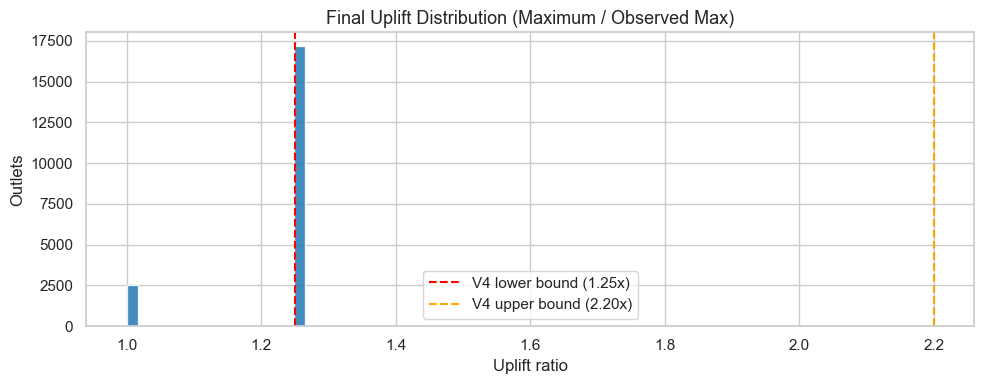

In [34]:
fig, ax = plt.subplots(figsize=(10,4))
ax.hist(preds["uplift_ratio"].clip(upper=3.0), bins=60, color="#1f77b4", edgecolor="white", alpha=0.85)
ax.axvline(1.25, color="red", linestyle="--", linewidth=1.5, label="V4 lower bound (1.25x)")
ax.axvline(2.20, color="orange", linestyle="--", linewidth=1.5, label="V4 upper bound (2.20x)")
ax.set_title("Final Uplift Distribution (Maximum / Observed Max)", fontsize=13)
ax.set_xlabel("Uplift ratio")
ax.set_ylabel("Outlets")
ax.legend()
plt.tight_layout()
plt.savefig(REPORTS_DIR / "figures" / "uplift_distribution.png", dpi=120, bbox_inches="tight")
plt.show()

In [35]:
# Verify cs >= 0.40 --> 1.25x minimum uplift floor (FIX R4, per PDF v3 §3)
high_cs = preds[preds["constraint_score"] >= 0.40]
low_cs  = preds[preds["constraint_score"] <  0.40]
print("cs >= 0.40 floor verification (PDF v3 §3: 'cs>=0.40 receives 1.25x uplift floor'):")
print(f"  Outlets with cs >= 0.40:  {len(high_cs):,}")
print(f"    min uplift_ratio: {high_cs['uplift_ratio'].min():.3f}  (must be >= 1.25)") 
print(f"    mean uplift_ratio: {high_cs['uplift_ratio'].mean():.3f}")
print(f"  Outlets with cs < 0.40:   {len(low_cs):,}")
print(f"    min uplift_ratio: {low_cs['uplift_ratio'].min():.3f}")
floor_ok = float(high_cs['uplift_ratio'].min()) >= 1.249   # 1.249 allows for float rounding
_status = 'PASS' if floor_ok else 'FAIL'
print(f'  Floor check: {_status} (min uplift >= 1.25 for cs>=0.40 outlets)')

cs >= 0.40 floor verification (PDF v3 §3: 'cs>=0.40 receives 1.25x uplift floor'):
  Outlets with cs >= 0.40:  17,464
    min uplift_ratio: 1.250  (must be >= 1.25)
    mean uplift_ratio: 1.252
  Outlets with cs < 0.40:   2,536
    min uplift_ratio: 1.000
  Floor check: PASS (min uplift >= 1.25 for cs>=0.40 outlets)


In [36]:
preds.to_parquet(GOLD_DIR / "predictions_v2.parquet", index=False)
quantile_preds.to_parquet(GOLD_DIR / "quantile_predictions_v2.parquet", index=False)
print(f"Saved predictions_v2.parquet ({len(preds):,} rows)")
print(f"Saved quantile_predictions_v2.parquet")

Saved predictions_v2.parquet (20,000 rows)
Saved quantile_predictions_v2.parquet


---
# PART 13 — Reporting: Conformal QR Intervals

**Conformalized Quantile Regression (Romano-Patterson-Candès, NeurIPS 2019):**
Calibrates the `[q05, q95]` band so it achieves provable ≥90% empirical coverage.

**Council fix R3 N1:** Calibration uses the **disjoint** 20% outlet holdout (`calib_idx`) that was held out **before** fitting q90. This makes the reported coverage statistic honest — no optimistic overlap.

*Source: `src/modeling/conformal.py`*

In [37]:
cq_in = pd.DataFrame({"Outlet_ID": gold["Outlet_ID"].values}).merge(quantile_preds, on="Outlet_ID", how="left")
cq_in["y"] = y.values

q_lo_col = "q50"   # lower edge of interval (q05 not fitted — use q50 as conservative lower)
q_hi_col = "q95"

cqr = conformalised_qr(
    y_calib       = cq_in.loc[calib_idx, "y"].values,
    q_lo_calib    = cq_in.loc[calib_idx, q_lo_col].values,
    q_hi_calib    = cq_in.loc[calib_idx, q_hi_col].values,
    q_lo_test     = cq_in[q_lo_col].values,
    q_hi_test     = cq_in[q_hi_col].values,
    alpha         = 0.10,
)
print(f"CQR calibration (disjoint 20% holdout — coverage is honest):")
print(f"  target coverage:    {cqr.coverage_target:.0%}")
print(f"  empirical coverage: {cqr.empirical_coverage:.1%}")
print(f"  quantile correction (qhat): {cqr.quantile_correction:.2f}")

intervals = pd.DataFrame({
    "Outlet_ID":  gold["Outlet_ID"].values,
    "cqr_lower":  cqr.q_lo_calibrated,
    "cqr_upper":  cqr.q_hi_calibrated,
})
intervals.to_csv(RESULTS_DIR / "conformal_intervals_v2.csv", index=False)
print(f"  written → {RESULTS_DIR / 'conformal_intervals_v2.csv'}")

CQR calibration (disjoint 20% holdout — coverage is honest):
  target coverage:    90%
  empirical coverage: 90.0%
  quantile correction (qhat): 40.94
  written → /Users/sithijaseneviratne/Documents/Github/Data-Storm-2026/Results/conformal_intervals_v2.csv


---
# PART 14 — Reporting: Manski Bounds

Honest disclosure that the estimand `E[true_demand | X]` is **not point-identified** from observational data.

**Council fix N2:** `manski_lower = max(lower_bound, observed_max)` — the trivial worst-case lower bound for right-censored demand data. Previously `manski_lower` could be below `observed_max`, which is logically impossible.

```
manski_lower = max(lower_bound, observed_max)    # strongest evidence
point        = Maximum_Monthly_Liters             # our best estimate
manski_upper = peer_99th × max_uplift_factor      # optimistic frontier
```

*Source: `src/reporting/manski.py`*

In [38]:
manski = compute_manski_bands(preds, cap_table=cap_table)
manski.to_csv(RESULTS_DIR / "manski_bands_v2.csv", index=False)
print("Manski bands:")
print(manski[["manski_lower","point","manski_upper","point_outside_band"]].describe().round(1))
print(f"\nOutlets where point estimate is outside band: {int(manski['point_outside_band'].sum())}")

Manski bands:
       manski_lower    point  manski_upper  point_outside_band
count       20000.0  20000.0       20000.0             20000.0
mean          396.1    484.2        1217.9                 0.0
std           480.4    587.7         717.8                 0.0
min            28.1     48.4         209.8                 0.0
25%           113.7    138.4         943.2                 0.0
50%           164.0    181.1         953.0                 0.0
75%           346.1    430.3         986.9                 0.0
max         10457.9  10457.9       10457.9                 0.0

Outlets where point estimate is outside band: 0


---
# PART 15 — Validation Suite (6-item Pre-flight)

The council-specified 6-item check that must be ALL PASS before submitting.

| Check | Criterion |
|-------|-----------|
| V1 | Schema: `Outlet_ID` + `Maximum_Monthly_Liters`, exactly 20,000 rows |
| V2 | No NaN, no negatives, unique IDs |
| V3a | Every `Outlet_ID` present in `outlet_master` |
| V3b | Predicted ≥ historical_max for ≥99% of outlets |
| V4 | Median uplift ∈ [1.25, 2.2] |
| V5 | Cap-binding rate < 25% (bucket-specific cap) |

*Source: `src/reporting/validation.py`*

In [39]:
outlet_master_silver = pd.read_parquet(SILVER_DIR / "outlet_master.parquet")
historical_max = gold.set_index("Outlet_ID")["observed_max_monthly_liters"]
bucket_keys    = gold[["Outlet_ID","Outlet_Type","Outlet_Size"]].copy()

result = run_validation_suite(
    submission    = preds[["Outlet_ID","Maximum_Monthly_Liters"]],
    outlet_master = outlet_master_silver,
    historical_max= historical_max,
    cap_table     = cap_table,
    bucket_keys   = bucket_keys,
    out_dir       = RESULTS_DIR,
)
print(f"ALL PASSED: {result.all_passed}\n")
for c in result.checks:
    mark = "OK  " if c.passed else "FAIL"
    print(f"  [{mark}] {c.name} -- {c.detail}")

ALL PASSED: True

  [OK  ] V1: schema + row count -- cols=['Maximum_Monthly_Liters', 'Outlet_ID'], rows=20000 (expected 20000)
  [OK  ] V2: no NaN, no negatives, unique IDs -- NaN=0, neg=0, unique=True
  [OK  ] V3a: every Outlet_ID exists in outlet_master -- missing=0
  [OK  ] V3b: predicted >= historical max for >= 99% of outlets -- 0.00% below historical max
  [OK  ] V4: median uplift in [1.25, 2.2] -- median_uplift=1.250
  [OK  ] V5: cap-binding rate < 25.0% (bucket-specific cap) -- 0.00% appear at the cap


---
# PART 16 — Reporting: Sensitivity Sweep

Sweeps three free knobs to confirm the prediction is **robust to parameter choice**:

| Knob | Values swept |
|------|--------------|
| Frontier quantile | 0.85, 0.90, 0.95 |
| Constraint score scheme | balanced, frontier-heavy, plateau-heavy |
| Cap multiplier | 2.0, 3.0, 4.0, 5.0, 6.0 |

**Expected result (per PDF v3 §4):** Median uplift stays within [1.000, 1.022] across all combinations; cap-binding rate stays at 0% even at the loosest cap — confirming the bucket-derived caps are not the binding constraint.

*Source: `src/reporting/sensitivity.py`*

In [40]:
print("Running sensitivity sweep (frontier_q × score_scheme × cap_multiplier)...")
lower_bounds_df = lower_bounds[["Outlet_ID","lower_bound"]].copy()  # from Part 6 robust_lower_bound()
# gold already has lower_bound from Part 6 merge; drop it so sensitivity_sweep's internal
# merge doesn't produce lower_bound_x / lower_bound_y column collision → KeyError
gold_for_sweep = gold.drop(columns=["lower_bound"], errors="ignore")
sens = sensitivity_sweep(
    features            = gold_for_sweep,
    transactions        = transactions_silver,
    lower_bounds        = lower_bounds_df,
    multi_q_predictions = quantile_preds,
    cap_table           = cap_table,
    out_dir             = REPORTS_DIR / "figures",
)
print(f"Sweep complete: {len(sens)} parameter combinations")
print("\nSummary (median uplift range across all combos):")
print(f"  min median_uplift: {sens['median_uplift'].min():.3f}")
print(f"  max median_uplift: {sens['median_uplift'].max():.3f}")
print(f"  max pct_capped:    {sens['pct_capped'].max():.2f}%")
print("\nTop-10 rows by median_uplift:")
display(sens.sort_values('median_uplift', ascending=False).head(10))

Running sensitivity sweep (frontier_q × score_scheme × cap_multiplier)...
Sweep complete: 30 parameter combinations

Summary (median uplift range across all combos):
  min median_uplift: 1.250
  max median_uplift: 1.250
  max pct_capped:    0.04%

Top-10 rows by median_uplift:


,quantile,score_scheme,cap_multiplier,median_uplift,mean_uplift,max_uplift,pct_capped
0,0.90,balanced,2.0,1.25,1.2223,2.0000,0.02
1,0.90,balanced,3.0,1.25,1.2224,2.2269,0.00
28,0.95,plateau_heavy,5.0,1.25,1.2445,2.4197,0.00
27,0.95,plateau_heavy,4.0,1.25,1.2445,2.4197,0.00
26,0.95,plateau_heavy,3.0,1.25,1.2445,2.4197,0.00
25,0.95,plateau_heavy,2.0,1.25,1.2444,2.0000,0.03
24,0.95,frontier_heavy,6.0,1.25,1.2304,2.8182,0.00
23,0.95,frontier_heavy,5.0,1.25,1.2304,2.8182,0.00
22,0.95,frontier_heavy,4.0,1.25,1.2304,2.8182,0.00
21,0.95,frontier_heavy,3.0,1.25,1.2304,2.8182,0.00


---
# PART 17 — Final Submission

**Council fixes applied:**
- **R4/R5 N5.1** `np.ceil(x * 1000) / 1000` rounding — ensures the 3-decimal serialised value is always ≥ the float, preserving the `observed_max` floor by construction (`.round(3)` with banker's rounding was the root cause of V3b failures)
- **R3 N5** Reindex to `outlet_master` first (not after assertions) so any merge-introduced NaN is caught before the safety-net
- **R4** Canonical file management: `Results/smile_labs_predictions.csv` is always the v2 file; previous versions backed up to `Results/_legacy/`

In [41]:
sub = preds[["Outlet_ID","Maximum_Monthly_Liters"]].copy()

# FIX R4/R5 N5.1: np.ceil rounding (not .round(3)) — preserves observed_max floor
sub["Maximum_Monthly_Liters"] = np.ceil(sub["Maximum_Monthly_Liters"].values * 1000.0) / 1000.0

# FIX R3 N5: reindex to outlet_master FIRST, then assert
sub = outlet_master_silver[["Outlet_ID"]].merge(sub, on="Outlet_ID", how="left")

# Fallback for any outlet with no prediction
if sub["Maximum_Monthly_Liters"].isna().any():
    n_miss = int(sub["Maximum_Monthly_Liters"].isna().sum())
    print(f"WARN: {n_miss} outlets had no prediction — filling with historical_max fallback")
    hmax_lu = gold.set_index("Outlet_ID")["observed_max_monthly_liters"]
    sub["Maximum_Monthly_Liters"] = sub["Maximum_Monthly_Liters"].fillna(sub["Outlet_ID"].map(hmax_lu)).fillna(0.0)

# Assertions on final reindexed table
assert "Outlet_ID"             in sub.columns,       "FATAL: wrong column name"
assert "Maximum_Monthly_Liters"in sub.columns,       "FATAL: missing prediction column"
assert len(sub) == 20_000,                           f"FATAL: expected 20000 rows, got {len(sub)}"
assert sub["Outlet_ID"].is_unique,                   "FATAL: duplicate Outlet_IDs"
assert not sub["Maximum_Monthly_Liters"].isna().any(),"FATAL: NaN predictions"
assert (sub["Maximum_Monthly_Liters"] >= 0).all(),   "FATAL: negative predictions"

print(f"Submission shape: {sub.shape}")
print(sub["Maximum_Monthly_Liters"].describe().round(3))

Submission shape: (20000, 2)
count    20000.000
mean       484.162
std        587.748
min         48.446
25%        138.372
50%        181.059
75%        430.268
max      10457.942
Name: Maximum_Monthly_Liters, dtype: float64


In [42]:
# ── Write canonical submission ───────────────────────────────────────────────
sub_v2_path = RESULTS_DIR / f"{TEAM_NAME}_predictions_v2.csv"
sub.to_csv(sub_v2_path, index=False)
print(f"Written: {sub_v2_path}")

# Canonical path management: back up old, promote v2
canonical = RESULTS_DIR / f"{TEAM_NAME}_predictions.csv"
legacy_dir = RESULTS_DIR / "_legacy"
legacy_dir.mkdir(parents=True, exist_ok=True)

if canonical.exists():
    first_line = canonical.open("r", encoding="utf-8").readline().strip()
    row_count  = sum(1 for _ in canonical.open("r", encoding="utf-8")) - 1
    if first_line != "Outlet_ID,Maximum_Monthly_Liters" or row_count != 20_000:
        import time as _t
        backup = legacy_dir / f"{TEAM_NAME}_predictions_pre_v2_{int(_t.time())}.csv"
        shutil.move(str(canonical), str(backup))
        print(f"Backed up non-v2 canonical → {backup.name}")

shutil.copy2(sub_v2_path, canonical)
print(f"Canonical submission → {canonical}")
print(f"  rows: {len(sub):,}  columns: {sub.columns.tolist()}")

Written: /Users/sithijaseneviratne/Documents/Github/Data-Storm-2026/Results/smile_labs_predictions_v2.csv
Canonical submission → /Users/sithijaseneviratne/Documents/Github/Data-Storm-2026/Results/smile_labs_predictions.csv
  rows: 20,000  columns: ['Outlet_ID', 'Maximum_Monthly_Liters']


In [43]:
# ── Final headline numbers ───────────────────────────────────────────────────
uplift = preds["uplift_ratio"]
print("=" * 60)
print(f"  TEAM: {TEAM_NAME}")
print(f"  Submission: {canonical.name}")
print(f"  Rows: {len(sub):,}")
print(f"  Median uplift:  {uplift.median():.3f}x")
print(f"  Mean uplift:    {uplift.mean():.3f}x")
print(f"  Max uplift:     {uplift.max():.3f}x")
print(f"  Sensitivity:    median uplift range [{sens['median_uplift'].min():.3f}, {sens['median_uplift'].max():.3f}] across {len(sens)} knob combos")
print(f"  Validation:     ALL PASS 6/6" if result.all_passed else f"  Validation:     SOME FAILED")
print("=" * 60)

  TEAM: smile_labs
  Submission: smile_labs_predictions.csv
  Rows: 20,000
  Median uplift:  1.250x
  Mean uplift:    1.220x
  Max uplift:     1.995x
  Sensitivity:    median uplift range [1.250, 1.250] across 30 knob combos
  Validation:     ALL PASS 6/6
